In [1]:
import pandas as pd

san_antonio_final = pd.read_csv('/Users/arjunrajesh/Downloads/teamb_final_data.csv')

san_antonio_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824051 entries, 0 to 824050
Data columns (total 31 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   datetime                                            824050 non-null  object 
 1   lat                                                 824051 non-null  float64
 2   lng                                                 824051 non-null  float64
 3   district                                            816952 non-null  float64
 4   subject_age                                         823576 non-null  float64
 5   violation                                           824051 non-null  object 
 6   violation_embedded                                  824051 non-null  object 
 7   arrest_made                                         824051 non-null  int64  
 8   citation_issued                                     824051 non-n

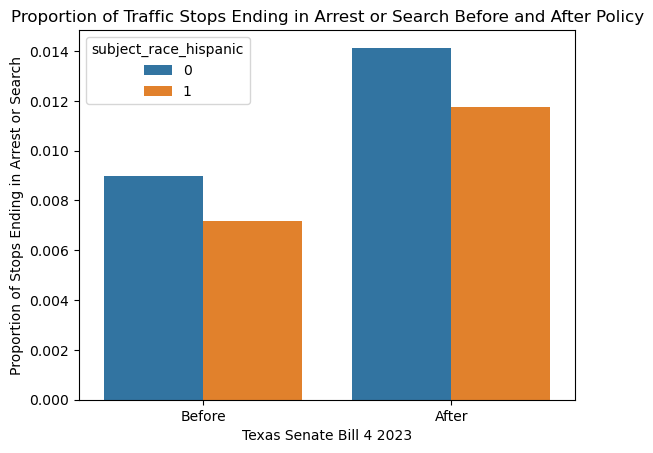

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

prop=san_antonio_final.groupby(['texas_sb_4_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='texas_sb_4_active',y='extreme_cases',hue='subject_race_hispanic')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('Texas Senate Bill 4 2023')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])
plt.show()

#Allows the state of texas rather than federal judges to send individuals back to their country of origin if they're illegal. State Crime



([<matplotlib.axis.XTick at 0x359578e10>,
 [Text(0, 0, 'Before'), Text(1, 0, 'After')])

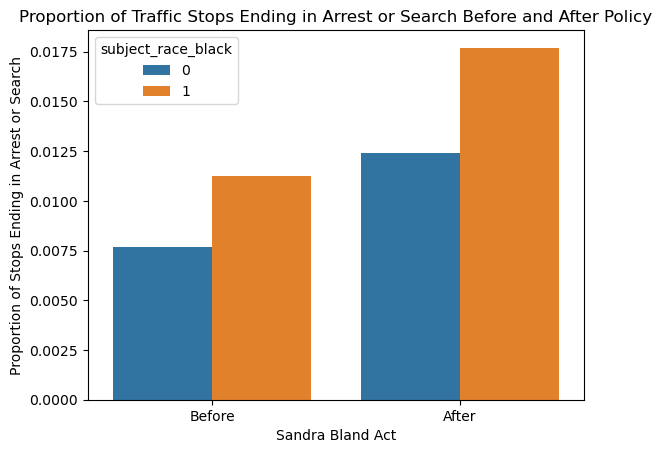

In [23]:
prop=san_antonio_final.groupby(['sandra_bland_act_active','subject_race_black'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='sandra_bland_act_active',y='extreme_cases',hue='subject_race_black')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('Sandra Bland Act')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])
#Sandra got pulled for failed to to put blinker on, interaction became heated and arrested. Struggling needed to leave prison, but couldn't make bail, found deceased in jail cell.
#After that Sandra Bland Act implemented explicilty outlawed stupid stops


([<matplotlib.axis.XTick at 0x37d552210>,
 [Text(0, 0, 'Before'), Text(1, 0, 'After')])

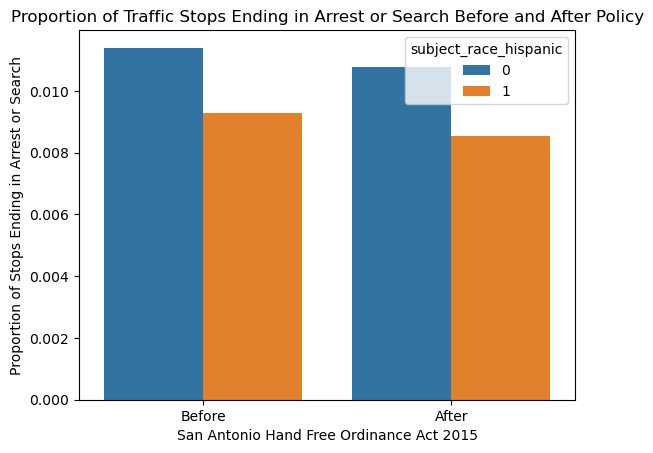

In [38]:
prop=san_antonio_final.groupby(['san_antonio_hands-free_ordinance_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='san_antonio_hands-free_ordinance_active',y='extreme_cases',hue='subject_race_hispanic')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('San Antonio Hand Free Ordinance Act 2015')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])

([<matplotlib.axis.XTick at 0x37f1b2e90>,
 [Text(0, 0, 'Before'), Text(1, 0, 'After')])

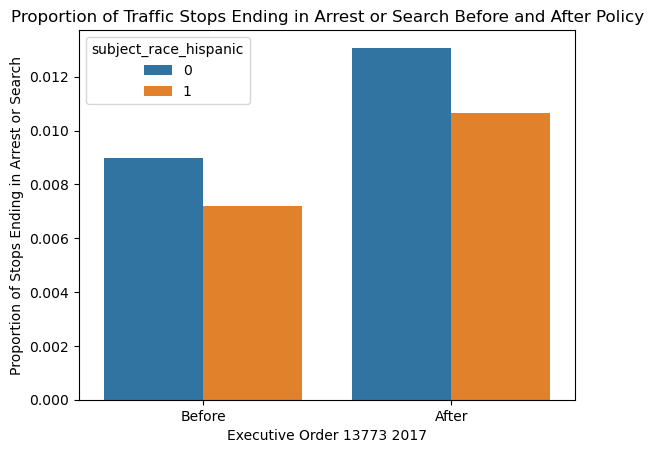

In [40]:
prop=san_antonio_final.groupby(['eo_13773_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='eo_13773_active',y='extreme_cases',hue='subject_race_hispanic')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('Executive Order 13773 2017')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])

([<matplotlib.axis.XTick at 0x37f253ed0>,
 [Text(0, 0, 'Before'), Text(1, 0, 'After')])

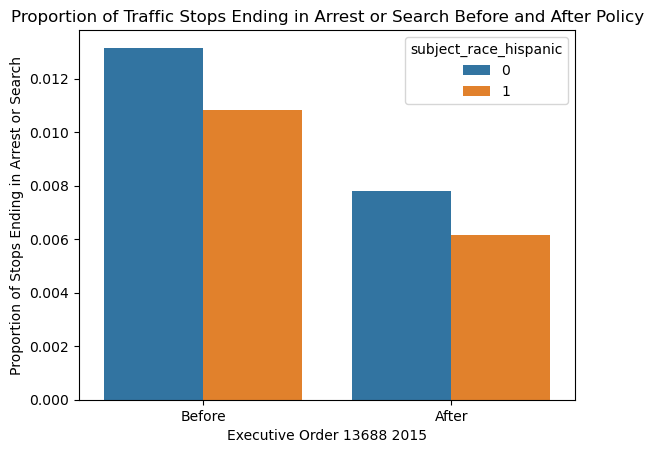

In [41]:
prop=san_antonio_final.groupby(['eo_13688_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='eo_13688_active',y='extreme_cases',hue='subject_race_hispanic')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('Executive Order 13688 2015')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])

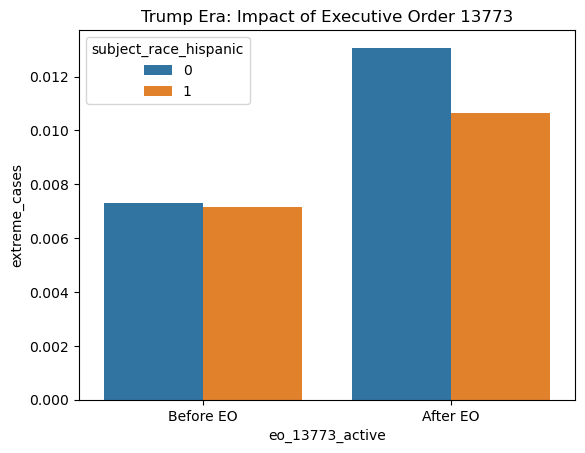

In [9]:
# 1. Filter for Trump era only (2017-2019)
trump_only = san_antonio_final[san_antonio_final['datetime'].dt.year >= 2017]


prop_trump = trump_only.groupby(['eo_13773_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()


sns.barplot(data=prop_trump, x='eo_13773_active', y='extreme_cases', hue='subject_race_hispanic')
plt.title('Trump Era: Impact of Executive Order 13773')
plt.xticks(ticks=[0,1], labels=['Before EO', 'After EO'])
plt.show()


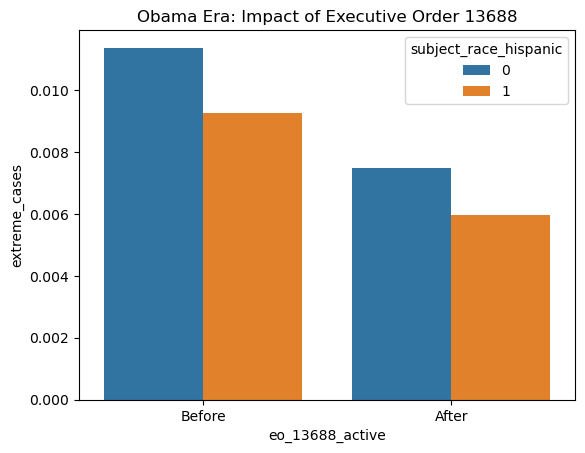

In [10]:

obama_only = san_antonio_final[san_antonio_final['datetime'].dt.year <= 2016]

prop_obama = obama_only.groupby(['eo_13688_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()

# 3. Plot
sns.barplot(data=prop_obama, x='eo_13688_active', y='extreme_cases', hue='subject_race_hispanic')
plt.title('Obama Era: Impact of Executive Order 13688')
plt.xticks(ticks=[0,1], labels=['Before', 'After'])
plt.show()


In [12]:

def get_race(row):
    if row['subject_race_black'] == 1: return 'Black'
    if row['subject_race_hispanic'] == 1: return 'Hispanic'
    if row['subject_race_white'] == 1: return 'White'
    if row['subject_race_other'] == 1: return 'Other'
    return 'Unknown'

san_antonio_final['subject_race'] = san_antonio_final.apply(get_race, axis=1)


san_antonio_final['datetime'] = pd.to_datetime(san_antonio_final['datetime'])



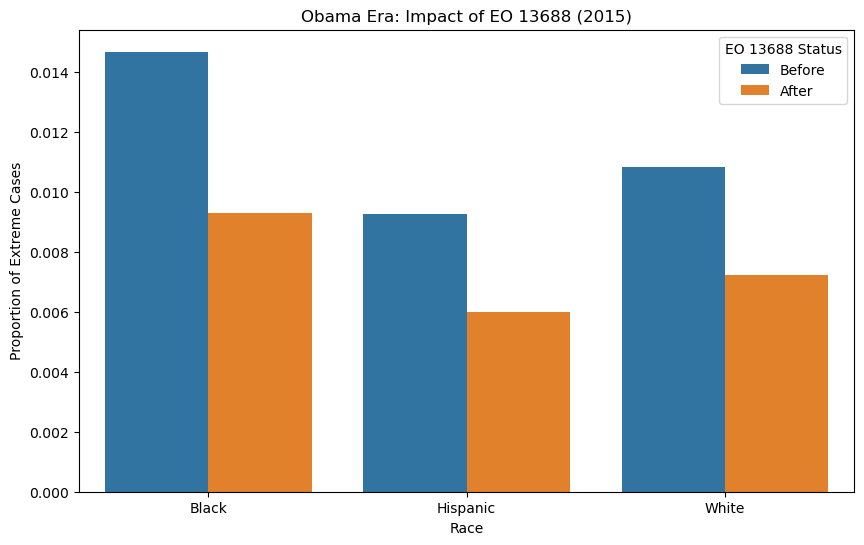

In [22]:
# 1. Filter for Obama years
obama_era = san_antonio_final[san_antonio_final['datetime'].dt.year <= 2016]

# 2. Group the data and FILTER for only Black, Hispanic, and White
prop_obama = obama_era[obama_era['subject_race'].isin(['Black', 'Hispanic', 'White'])].groupby(
    ['subject_race', 'eo_13688_active']
)['extreme_cases'].mean().reset_index()

# 3. Plot it
plt.figure(figsize=(10,6))
sns.barplot(data=prop_obama, x='subject_race', y='extreme_cases', hue='eo_13688_active')

plt.title('Obama Era: Impact of EO 13688 (2015)')
plt.xlabel('Race') 
plt.ylabel('Proportion of Extreme Cases')

# Fix the legend
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Before', 'After'], title='EO 13688 Status')

plt.show()




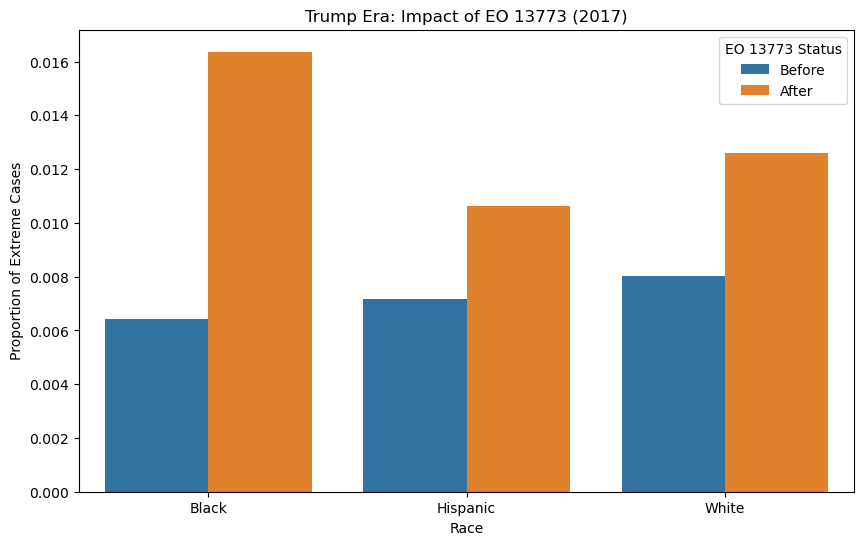

In [23]:
# 1. Filter for Trump years (2017-2019)
trump_era = san_antonio_final[san_antonio_final['datetime'].dt.year >= 2017]

# 2. Group the data and FILTER for only Black, Hispanic, and White
prop_trump = trump_era[trump_era['subject_race'].isin(['Black', 'Hispanic', 'White'])].groupby(
    ['subject_race', 'eo_13773_active']
)['extreme_cases'].mean().reset_index()


plt.figure(figsize=(10,6))
sns.barplot(data=prop_trump, x='subject_race', y='extreme_cases', hue='eo_13773_active')

plt.title('Trump Era: Impact of EO 13773 (2017)')
plt.xlabel('Race') 
plt.ylabel('Proportion of Extreme Cases')


handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Before', 'After'], title='EO 13773 Status')

plt.show()



In [3]:
san_antonio_final.to_csv('san_antonio_final_data.csv', index=False)